# lightshap — Fast Tabular Attribution

LightSHAP is a zero-dependency, Polars-native library for fast tabular Shapley value attribution that also provides standard errors alongside its estimates but has no interaction index support. This notebook benchmarks lightshap's runtime and explanation faithfulness against `shapiq` on both benchmark datasets, highlighting the speed-accuracy trade-off of its lightweight design. The evaluation focuses on single-index attribution quality and how it scales with feature count.

In [7]:
from Models.load_and_train import TrainingConfig
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightshap import explain_any
from shapiq import ExactExplainer
from tqdm.auto import tqdm

# sklearn RandomForest Modelle laden
all_combi_configs = TrainingConfig.get_all_configs(pytorch=False)
all_trained_models = [config.train(verbose=True) for config in all_combi_configs]

print("✅ Alle Modelle erfolgreich trainiert!")

Trained random_forest_regressor on california_housing
Trained random_forest_regressor on ames_housing
Trained random_forest_regressor on covertype
✅ Alle Modelle erfolgreich trainiert!


In [18]:
results = []

for config, model in tqdm(zip(all_combi_configs, all_trained_models), total=len(all_combi_configs), desc="Processing datasets"):
    data = config.dataset.load_dataset()
    X = data["X"]
    feature_names = data["feature_names"]
    name = data["name"]
    task = data["task"]

    X_eval = X.iloc[100:120]
    bg = X.iloc[:100]

    print(f"\n=== {name} ({task}) ===")

    # === LightSHAP ===
    start = time.time()
    explanation = explain_any(model.predict, X_eval, bg_X=bg)
    lightshap_time = time.time() - start

    if hasattr(explanation, "values") and explanation.values is not None:
        lightshap_vals = explanation.values
    elif hasattr(explanation, "shap_values"):
        lightshap_vals = explanation.shap_values
    else:
        lightshap_vals = np.asarray(explanation)

    if lightshap_vals.ndim == 3:
        lightshap_vals = lightshap_vals.mean(axis=2)
    # shape: (n_samples, n_features)

    # === True SHAP via shapiq ===
    try:
        from shapiq import TabularExplainer

        bg_numpy = bg.to_numpy()
        feature_names_list = list(X.columns)
        n_features = bg_numpy.shape[1]

        # Wrapper: verhindert sklearn Feature-Name-Warning
        def model_predict_numpy(x):
            df = pd.DataFrame(x, columns=feature_names_list)
            return model.predict(df)

        start = time.time()
        shapiq_explainer = TabularExplainer(
            model=model_predict_numpy,
            data=bg_numpy,
            index="SV",
            max_order=1
        )

        true_shap_list = []
        for i in range(len(X_eval)):
            x_instance = X_eval.iloc[i].to_numpy()
            explanation_obj = shapiq_explainer.explain(x_instance, budget=2048)

            # InteractionValues: Werte über interaction_lookup extrahieren
            sv_array = np.zeros(n_features)
            try:
                # Methode 1: get_n_order_values (sauberste API)
                sv_array = explanation_obj.get_n_order_values(1)
            except AttributeError:
                try:
                    # Methode 2: interaction_lookup
                    for pos, key in enumerate(explanation_obj.interaction_lookup):
                        if len(key) == 1:
                            sv_array[key[0]] = explanation_obj.values[pos]
                except AttributeError:
                    # Methode 3: direkt über .values wenn shape passt
                    if hasattr(explanation_obj, "values") and len(explanation_obj.values) == n_features:
                        sv_array = np.array(explanation_obj.values)

            true_shap_list.append(sv_array)

        true_shap_vals = np.array(true_shap_list)  # (n_samples, n_features)
        true_time = time.time() - start

        lightshap_mean = lightshap_vals.mean(axis=0)   # (n_features,)
        true_shap_mean = true_shap_vals.mean(axis=0)   # (n_features,)

        # NaN-sicherer corrcoef
        if np.std(lightshap_mean) < 1e-10 or np.std(true_shap_mean) < 1e-10:
            correlation = None
            print(f"  Warnung: Vektor hat std≈0, Korrelation nicht berechenbar")
        else:
            correlation = np.corrcoef(lightshap_mean, true_shap_mean)[0, 1]

        corr_str = f"{correlation:.4f}" if correlation is not None else "N/A"
        print(f"  LightSHAP: {lightshap_time:.3f}s | True SHAP: {true_time:.3f}s | Corr: {corr_str}")

    except Exception as e:
        import traceback
        true_time = None
        correlation = None
        print(f"  (True SHAP fehlgeschlagen: {e})")
        traceback.print_exc()

    results.append({
        "Dataset": name,
        "LightSHAP Time (s)": round(lightshap_time, 3),
        "True SHAP Time (s)": round(true_time, 3) if true_time is not None else "-",
        "Correlation": round(correlation, 4) if correlation is not None else "-",
        "Mean |LightSHAP|": round(float(np.abs(lightshap_vals.mean(axis=0)).mean()), 4),
    })

print("\n" + "="*70)
print(" LIGHTSHAP BENCHMARK ERGEBNISSE")
print("="*70)
df_results = pd.DataFrame(results)
display(df_results)

Processing datasets:   0%|          | 0/3 [00:00<?, ?it/s]


=== California Housing (regression) ===
Permutation SHAP (exact)


100%|██████████| 20/20 [00:01<00:00, 11.11it/s]
/Users/maga/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/shapiq/approximator/regression/base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
/Users/maga/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/shapiq/approximator/regression/base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
/Users/maga/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/shapiq/approximator/regression/base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
/Users/maga/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/shapiq/approximator/regression/base.py:159: UserWarning: Not all budget is required due to the border-trick.
  self._sampler.sample(budget)
/Users/maga/PR_ModeAgnostic/.venv/lib/python3.13/site-packages/shapiq/approximator/regression/base.py:159: UserWarning: Not all budget is re

  LightSHAP: 1.848s | True SHAP: 8.745s | Corr: 1.0000

=== Ames Housing (regression) ===
Kernel SHAP (hybrid degree 1, 21% exact)


Processing datasets:  67%|██████▋   | 2/3 [00:53<00:29, 29.63s/it]

  LightSHAP: 17.440s | True SHAP: 25.452s | Corr: 0.9957

=== Forest Covertype (classification) ===
Kernel SHAP (hybrid degree 1, 22% exact)


100%|██████████| 20/20 [02:40<00:00,  8.03s/it]
/var/folders/fz/tgv57mws2sj2s9117_dqg0sc0000gn/T/ipykernel_53057/282305292.py:17: UserWarning: 1 rows did not converge. Consider using a larger tol or higher max_iter.
  explanation = explain_any(model.predict, X_eval, bg_X=bg)
Processing datasets: 100%|██████████| 3/3 [04:05<00:00, 81.74s/it] 

  LightSHAP: 160.703s | True SHAP: 30.706s | Corr: 0.7152

 LIGHTSHAP BENCHMARK ERGEBNISSE


,Dataset,LightSHAP Time (s),True SHAP Time (s),Correlation,Mean |LightSHAP|
0,California Housing,1.848,8.745,1.0000,0.1441
1,Ames Housing,17.440,25.452,0.9957,354.6952
2,Forest Covertype,160.703,30.706,0.7152,0.0053


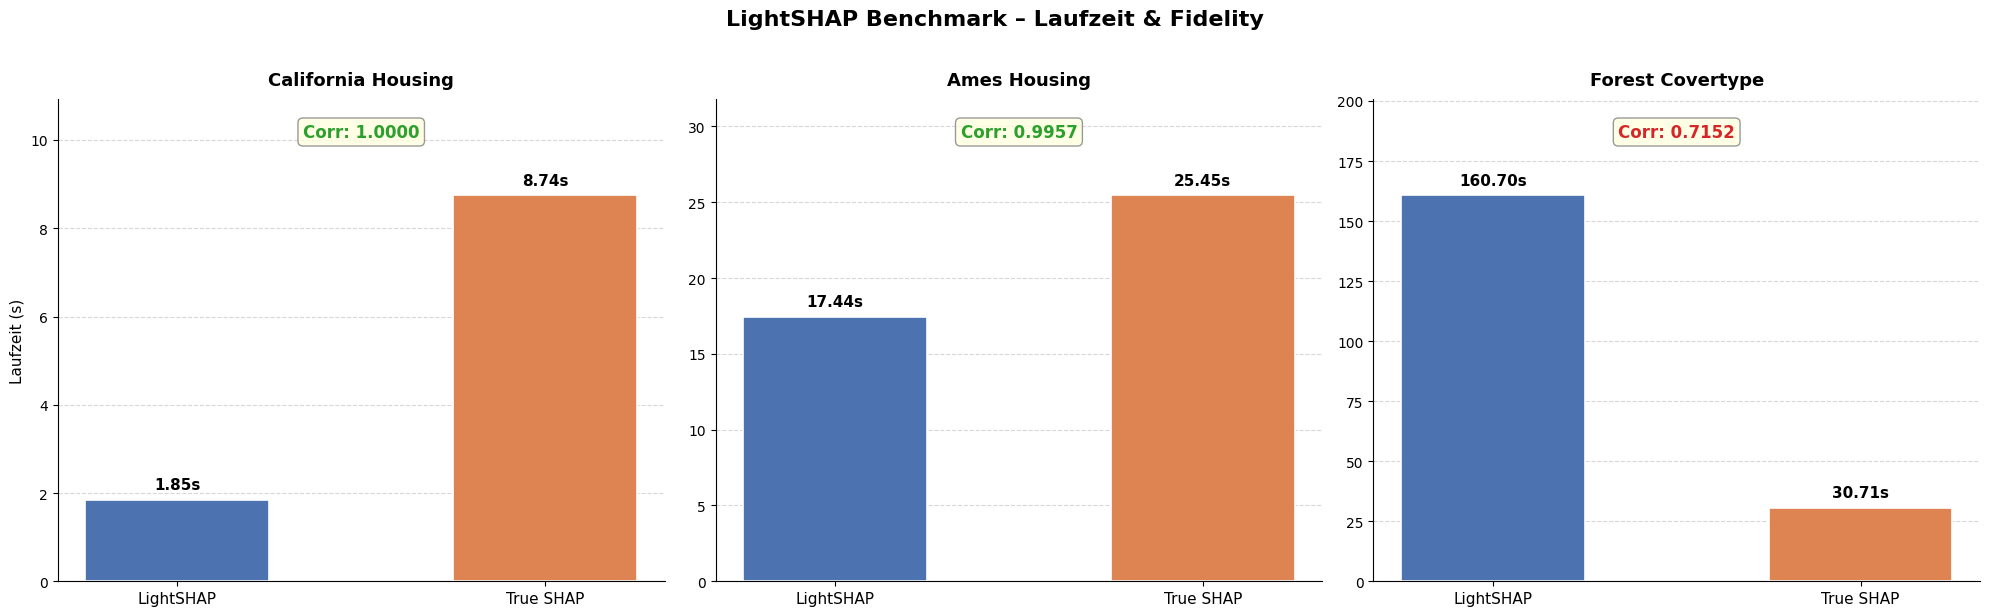

In [20]:
import warnings
warnings.filterwarnings("ignore")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = {
    "LightSHAP": "#4C72B0",
    "True SHAP": "#DD8452",
}

for idx, (_, row) in enumerate(df_results.iterrows()):
    ax = axes[idx]
    dataset_name = row["Dataset"]

    times = {"LightSHAP": row["LightSHAP Time (s)"], "True SHAP": row["True SHAP Time (s)"]}
    labels = list(times.keys())
    values = [v if v != "-" else 0 for v in times.values()]
    bar_colors = [colors[l] for l in labels]

    bars = ax.bar(labels, values, color=bar_colors, width=0.5, edgecolor="white", linewidth=1.2)

    # Werte über den Balken
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.02,
                f"{val:.2f}s",
                ha="center", va="bottom", fontsize=11, fontweight="bold"
            )

    # Korrelation als Annotation
    corr = row["Correlation"]
    corr_str = f"Corr: {corr:.4f}" if corr != "-" else "Corr: N/A"
    ax.text(
        0.5, 0.95, corr_str,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=12, fontweight="bold",
        color="#2ca02c" if corr != "-" and float(corr) > 0.9 else "#d62728",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray", alpha=0.8)
    )

    ax.set_title(dataset_name, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Laufzeit (s)" if idx == 0 else "", fontsize=11)
    ax.set_ylim(0, max(values) * 1.25 if max(values) > 0 else 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle("LightSHAP Benchmark – Laufzeit & Fidelity", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("lightshap_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()